# The final system, end to end: trained OCR vs ground-truth OCR

The same pipeline (redaction → extraction → dbt checks) run twice on the 200 receipts:

- **ground truth**: the annotated words and boxes (`--ocr ground_truth`), i.e. perfect OCR;
- **models**: DBNet finds the words and the fine-tuned TrOCR reads them (`--ocr model`).

Everything after OCR is identical, so **every difference is error added by OCR**. Each run was exported per receipt
with `python -m data_platform.pipeline.snapshot results/<run>.csv`; this notebook only reads those files.

Both models were trained on the train split (140 receipts) and selected on val (30), so the **test split (30
receipts)** is the honest estimate; numbers on all receipts are shown for scale.

The model run was stopped after OCR had read 164 of the 200 receipts (about 18 s per receipt on CPU), so the
comparison covers the receipts both runs processed, including 25 of the 30 test receipts. The other 36 are still
`pending`; `python -m data_platform.pipeline.run --ocr model` (without `--reset`) finishes them.

In [1]:
import json, os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if not os.path.isdir("results") and os.path.isdir("../results"):
    os.chdir("..")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

gt = pd.read_csv("results/system_ground_truth.csv").set_index("file_name")
mo = pd.read_csv("results/system_models.csv").set_index("file_name")
both = gt.join(mo, lsuffix="_gt", rsuffix="_mo")
coverage = pd.crosstab(both.split_gt, both.outcome_mo == "pending").rename(columns={False: "processed", True: "not processed"})
print(coverage.to_string()); print()
both = both[both.outcome_mo != "pending"]  # compare only receipts the model run processed
OUTCOMES = ["published", "quarantined", "extract_failed", "ocr_failed", "redact_failed"]
print(f"{len(both)} receipts | ground truth run OCR: {gt.ocr_source.iloc[0]} | model run OCR: {mo.ocr_source.iloc[0]}")

outcome_mo  processed  not processed
split_gt                            
test               25              5
train             115             25
val                24              6

164 receipts | ground truth run OCR: ground_truth | model run OCR: model


## 1. Outcomes: how many receipts make it through

test split (25 held-out receipts)
                  published  quarantined  extract_failed  published %
ground-truth OCR         15            8               2         60.0
trained models           13           10               2         52.0

all processed receipts (164)
                  published  quarantined  extract_failed  published %
ground-truth OCR        115           33              16         70.1
trained models          111           37              16         67.7



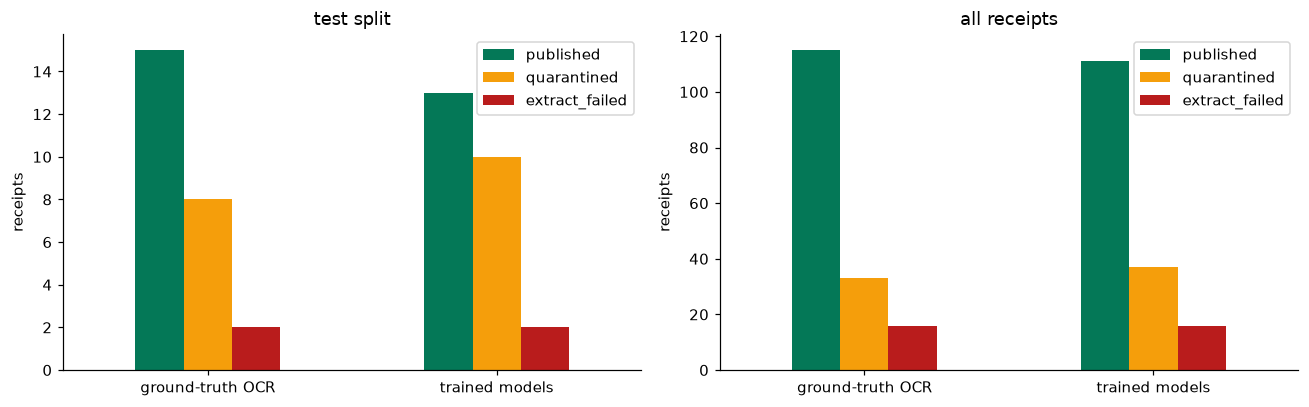

In [2]:
def outcome_table(subset):
    t = pd.DataFrame({name: subset[col].value_counts().reindex(OUTCOMES, fill_value=0)
                      for name, col in (("ground-truth OCR", "outcome_gt"), ("trained models", "outcome_mo"))}).T
    t = t.loc[:, (t > 0).any() | t.columns.isin(["published", "quarantined", "extract_failed"])]
    t["published %"] = (t["published"] / len(subset) * 100).round(1)
    return t

for label, subset in ((f"test split ({(both.split_gt == 'test').sum()} held-out receipts)", both[both.split_gt == "test"]),
                      (f"all processed receipts ({len(both)})", both)):
    print(label); print(outcome_table(subset).to_string()); print()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=False)
for ax, (label, subset) in zip(axes, (("test split", both[both.split_gt == "test"]), ("all receipts", both))):
    t = outcome_table(subset)[["published", "quarantined", "extract_failed"]]
    t.plot.bar(ax=ax, rot=0, color=["#047857", "#F59E0B", "#B91C1C"], title=label)
    ax.set_ylabel("receipts")
plt.tight_layout(); plt.show()

## 2. Where each receipt went: ground-truth outcome → model outcome

In [3]:
for label, subset in (("test split", both[both.split_gt == "test"]), ("all receipts", both)):
    print(label)
    print(pd.crosstab(subset.outcome_gt, subset.outcome_mo, rownames=["ground truth ↓"], colnames=["models →"]).to_string())
    print()

test split
models →        extract_failed  published  quarantined
ground truth ↓                                        
extract_failed               1          1            0
published                    1         12            2
quarantined                  0          0            8

all receipts
models →        extract_failed  published  quarantined
ground truth ↓                                        
extract_failed              13          3            0
published                    2        104            9
quarantined                  1          4           28



## 3. On receipts published by both runs, do the extracted fields agree?

Published means the receipt passed every dbt check in both runs. The question is whether the models produced the
**same values** as perfect OCR, or values that happen to be consistent but differ.

In [4]:
def items(s):
    return json.loads(s) if isinstance(s, str) else []

def agreement(subset):
    pub = subset[(subset.outcome_gt == "published") & (subset.outcome_mo == "published")]
    same = lambda a, b: (pub[a].fillna(-1) == pub[b].fillna(-1))
    gt_items = [items(s) for s in pub.items_gt]; mo_items = [items(s) for s in pub.items_mo]
    amounts_found = sum(len({i[2] for i in g} & {i[2] for i in m}) for g, m in zip(gt_items, mo_items))
    names_exact = sum(len({i[0] for i in g} & {i[0] for i in m}) for g, m in zip(gt_items, mo_items))
    n_gt_items = sum(len(g) for g in gt_items)
    return pd.Series({
        "receipts published by both": len(pub),
        "same total": same("total_gt", "total_mo").mean(),
        "same number of items": same("n_items_gt", "n_items_mo").mean(),
        "same cash": same("cash_gt", "cash_mo").mean(),
        "same change": same("change_gt", "change_mo").mean(),
        "same payment method": (pub.payment_method_gt.fillna("") == pub.payment_method_mo.fillna("")).mean(),
        "item amounts recovered": amounts_found / max(n_gt_items, 1),
        "item names exactly equal": names_exact / max(n_gt_items, 1),
    })

table = pd.DataFrame({"test split": agreement(both[both.split_gt == "test"]), "all receipts": agreement(both)})
print(table.to_string(float_format=lambda v: f"{v:.3f}" if v < 2 else f"{v:.0f}"))

                            test split  all receipts
receipts published by both          12           104
same total                       1.000         0.990
same number of items             1.000         0.981
same cash                        1.000         0.942
same change                      1.000         0.971
same payment method              0.917         0.923
item amounts recovered           0.906         0.919
item names exactly equal         0.594         0.654


In [5]:
pub = both[(both.outcome_gt == "published") & (both.outcome_mo == "published")]
diff = pub[pub.total_gt.fillna(-1) != pub.total_mo.fillna(-1)]
print(f"{len(diff)} receipts published by both with a different total:")
print(diff[["split_gt", "total_gt", "total_mo", "n_items_gt", "n_items_mo"]].to_string())

1 receipts published by both with a different total:
                      split_gt  total_gt  total_mo  n_items_gt  n_items_mo
file_name                                                                 
dev_receipt_00025.png    train  207900.0       7.0         7.0         7.0


## 4. Receipts lost to OCR errors: published with perfect OCR, not with the models

In [6]:
lost = both[(both.outcome_gt == "published") & (both.outcome_mo != "published")]
print(f"{len(lost)} receipts ({(lost.split_gt == 'test').sum()} in the test split)")
reasons = lost.apply(lambda r: r.failed_checks_mo if r.outcome_mo == "quarantined" else f"{r.outcome_mo}: {r.error_mo}", axis=1)
print(reasons.value_counts().to_string())
print()
print(lost[["split_gt", "outcome_mo", "total_gt", "total_mo", "mean_confidence_mo"]].head(15).to_string())

11 receipts (3 in the test split)
items_do_not_reconcile                               7
extract_failed: ValueError: no TOTAL amount found    2
change_inconsistent                                  1
items_do_not_reconcile,change_inconsistent           1

                       split_gt      outcome_mo  total_gt  total_mo  mean_confidence_mo
file_name                                                                              
dev_receipt_00022.png     train     quarantined  308000.0  308000.0            0.977585
dev_receipt_00034.png     train     quarantined  283338.0  283338.0            0.978281
dev_receipt_00035.png     train     quarantined  304326.0  304326.0            0.979528
dev_receipt_00057.png     train     quarantined  288585.0  288585.0            0.978104
dev_receipt_00077.png     train     quarantined   58000.0   58000.0            0.941841
test_receipt_00004.png     test  extract_failed  174600.0       NaN            0.755937
test_receipt_00005.png    train     quara

## 5. OCR signals: token counts, confidence and PII

                  tokens per receipt  mean confidence  PII tokens masked
ground-truth OCR              22.616            1.000                  1
trained models                23.128            0.966                  2


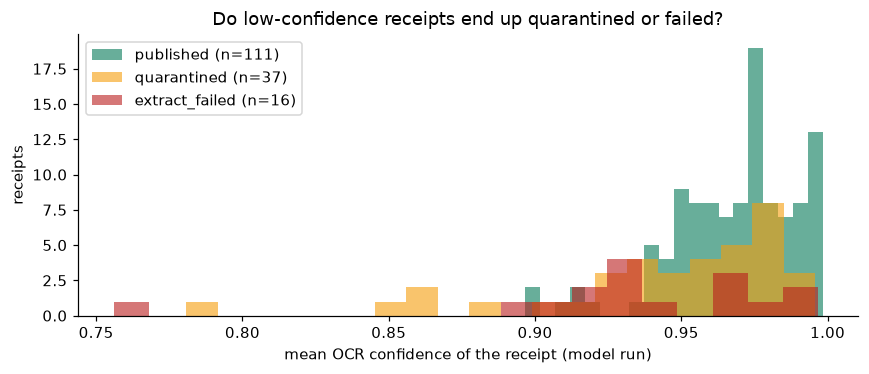

In [7]:
summary = pd.DataFrame({
    "tokens per receipt": [gt.n_tokens.mean(), mo.n_tokens.mean()],
    "mean confidence": [gt.mean_confidence.mean(), mo.mean_confidence.mean()],
    "PII tokens masked": [gt.loc[both.index].n_pii.sum(), mo.loc[both.index].n_pii.sum()],
}, index=["ground-truth OCR", "trained models"])
summary.loc["ground-truth OCR", "tokens per receipt"] = gt.loc[both.index].n_tokens.mean()
summary.loc["trained models", "tokens per receipt"] = mo.loc[both.index].n_tokens.mean()
print(summary.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
for outcome, color in (("published", "#047857"), ("quarantined", "#F59E0B"), ("extract_failed", "#B91C1C")):
    vals = mo[mo.outcome == outcome].mean_confidence.dropna()
    if len(vals):
        ax.hist(vals, bins=20, alpha=0.6, color=color, label=f"{outcome} (n={len(vals)})")
ax.set_xlabel("mean OCR confidence of the receipt (model run)"); ax.set_ylabel("receipts"); ax.legend()
ax.set_title("Do low-confidence receipts end up quarantined or failed?")
plt.tight_layout(); plt.show()